# **IMPORTS**

In [1]:
from transformers import AutoModelForImageClassification, AutoProcessor
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import requests
import matplotlib.pyplot as plt
import random
import numpy as np
import sys
import math

# **INITIALISATION**

In [2]:
# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

<function matplotlib.pyplot.show(close=None, block=None)>

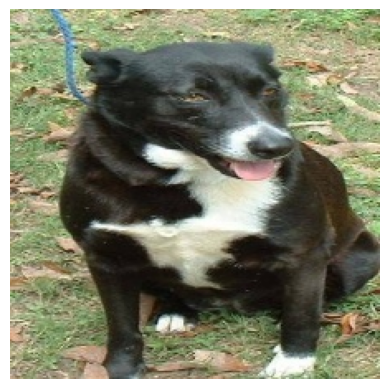

In [3]:
image = Image.open("/content/sample_data/dog.jpg")

plt.imshow(image)
plt.axis("off")
plt.show

In [4]:
from transformers import AutoImageProcessor

model_name = "hilmansw/resnet18-catdog-classifier"

model = AutoModelForImageClassification.from_pretrained(model_name).to(device)
model.eval()

# processor = AutoProcessor.from_pretrained(model_name)
# print(processor)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/696 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/44.8M [00:00<?, ?B/s]

ResNetForImageClassification(
  (resnet): ResNetModel(
    (embedder): ResNetEmbeddings(
      (embedder): ResNetConvLayer(
        (convolution): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activation): ReLU()
      )
      (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (encoder): ResNetEncoder(
      (stages): ModuleList(
        (0): ResNetStage(
          (layers): Sequential(
            (0): ResNetBasicLayer(
              (shortcut): Identity()
              (layer): Sequential(
                (0): ResNetConvLayer(
                  (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                  (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                  (activation): ReLU()
           

In [5]:
# Les Transforms

transformTensor = transforms.ToTensor()

transformPIL = transforms.ToPILImage()

transformIn = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),  # -> je ne suis pas sûr de moi
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalisation -> ImageNet
])

transformOut = transforms.Compose([
    transforms.Normalize(
        mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
        std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
    )
])

# **METHODS**

In [6]:
def multiple_copies_generator(image, number_of_copies = 40):
    return image.unsqueeze(0).expand(number_of_copies, -1, -1, -1).to(device) # Format [number_of_copies, 3, x, y]

In [7]:
import torch

def pixel_to_change_generator(image, lower_pourcentage=0.001, upper_pourcentage=0.01):
    _, height, width = image.shape
    random_pourcentage = torch.FloatTensor(1).uniform_(lower_pourcentage, upper_pourcentage).to(device)
    pixel_to_change = (random_pourcentage * (height * width)).floor().int().item()

    return pixel_to_change#, random_pourcentage.item()

In [8]:
def apply_convolution(tensor, kernel):
    return F.conv2d(tensor.unsqueeze(0).unsqueeze(0), kernel, padding=kernel.shape[2]//2)

In [18]:
# GOOD VERSION, only difference is the way values_to_change is computed

# Rather to modify random pixels
# It modifies pixels next to edges to have a greater impact
# To do that i divide the image into x matrices
# And i use sobel convolution matrices to evaluate the likelyhood to have a sharp edge
# I then take x matrices with the most score and randomly change them

# If elite_matrices = 2; it means 2 matrices changed per channel so 6 modification -> 2 x 3
# But if elite_matrices = 2 and targeted is True it means only 2 modification

# ⚠️ Bigger dividers means adding noise closer to the edges!
#     The max amount of elite_matrices is always divider x divider; divider = 7; 7x7 => 49 => max amount of elite_matrices
#     Control the total noise added with divider and elite_matrice

def noise_generator_edge(multiple_copies, reach = 1, divider = 7, elite_matrices=2, square_root=False, targeted=False, targeted_channel=0): # reach = 0.1  ->  -0.1 <= x <= 0.1

    batch_size, channels, height, width = multiple_copies.shape

    multiple_copies = multiple_copies.clone().to(device)

    image = multiple_copies[0]

    # Convolution matrices
    sobel_horizontal = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    sobel_vertical = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    sobel_diagonal1 = torch.tensor([[0, 1, 2],
                                    [-1, 0, 1],
                                    [-2, -1, 0]], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    sobel_diagonal2 = torch.tensor([[2, 1, 0],
                                    [1, 0, -1],
                                    [0, -1, -2]], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)



    sub_matrix_size = int(height/divider) # exemple -> 224/7 => 32; 7x7 => 49 matrices of 32x32 pixels in the 224x224 image

    if targeted: channels = 1

    for c in range(channels): # I take each channels to evaluate them individually

      if targeted: c = targeted_channel # Rather than having x matrices changed per channel we have x*3 matrices changed for the targeted channel

      sub_matrices = []
      sub_scores = []

      for h in range(divider): # height iteration
          for w in range(divider): # width iteration

              sub_matrix = image[c, h*sub_matrix_size:(h+1)*sub_matrix_size, w*sub_matrix_size:(w+1)*sub_matrix_size]
              sub_matrices.append(sub_matrix)

              score_horizontal = apply_convolution(sub_matrix, sobel_horizontal).abs().sum().item() # return a matrice of likelihood to have an edge; we then sum up those likelihood to have a score
              score_vertical = apply_convolution(sub_matrix, sobel_vertical).abs().sum().item()
              score_diagonal1 = apply_convolution(sub_matrix, sobel_diagonal1).abs().sum().item()
              score_diagonal2 = apply_convolution(sub_matrix, sobel_diagonal2).abs().sum().item()

              score_total = score_horizontal + score_vertical

              sub_scores.append(score_total)

      top_indices = torch.topk(torch.tensor(sub_scores), elite_matrices).indices # Take the x best score

      for index in top_indices:
        # Set the location for the pixels to change and for each dimensions -> int64 for indexing

        zone_height = int(index//divider) # Get the height start
        zone_width = int(index%divider) # Get the width start

        #Modify the square root of the total amount of pixel in the matrix
        if square_root:
          # Randomly choose an index for each dimensions
          pixel_c = torch.full((batch_size, sub_matrix_size), c, dtype=torch.int64).to(device)
          pixel_y = torch.stack([torch.randperm(sub_matrix_size) + zone_height * sub_matrix_size for _ in range(batch_size)]).to(device) # no duplicate
          pixel_x = torch.stack([torch.randperm(sub_matrix_size) + zone_width * sub_matrix_size for _ in range(batch_size)]).to(device)

          values_to_change = torch.empty(batch_size, sub_matrix_size).uniform_(-reach, reach).to(device)

        # Modify the entirety of the matrix
        else:
          pixel_c = torch.full((batch_size, sub_matrix_size**2), c, dtype=torch.int64).to(device)
          pixel_y = torch.arange(zone_height * sub_matrix_size, (zone_height + 1) * sub_matrix_size).repeat(sub_matrix_size)  # Repeats 0-31 for each row
          pixel_x = torch.arange(zone_width * sub_matrix_size, (zone_width + 1) * sub_matrix_size).repeat_interleave(sub_matrix_size)  # Expands 0-31 across all columns

          # Reshape to (40, 1024)
          pixel_y = pixel_y.unsqueeze(0).repeat(batch_size, 1)
          pixel_x = pixel_x.unsqueeze(0).repeat(batch_size, 1)

          # Create a tensor with the values to add (+ and -)
          values_to_change = torch.empty(batch_size, sub_matrix_size**2).uniform_(-reach, reach).to(device)

        multiple_copies[torch.arange(batch_size).unsqueeze(1), pixel_c, pixel_x, pixel_y] += values_to_change

    return multiple_copies.clamp_(0, 1)

In [22]:
# BEST VERSION

# Rather to modify random pixels
# It modifies pixels next to edges to have a greater impact
# To do that i divide the image into x matrices
# And i use sobel convolution matrices to evaluate the likelyhood to have a sharp edge
# I then take x matrices with the most score and randomly change them

# If elite_matrices = 2; it means 2 matrices changed per channel so 6 modification -> 2 x 3
# But if elite_matrices = 2 and targeted is True it means only 2 modification

# ⚠️ Bigger dividers means adding noise closer to the edges!
#     The max amount of elite_matrices is always divider x divider; divider = 7; 7x7 => 49 => max amount of elite_matrices
#     Control the total noise added with divider and elite_matrice

def noise_generator_edge(multiple_copies, reach = 1, divider = 7, elite_matrices=2, targeted=False, targeted_channel=0): # reach = 0.1  ->  -0.1 <= x <= 0.1

    batch_size, channels, height, width = multiple_copies.shape

    multiple_copies = multiple_copies.clone().to(device)

    image = multiple_copies[0]

    # Convolution matrices
    sobel_horizontal = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    sobel_vertical = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    sobel_diagonal1 = torch.tensor([[0, 1, 2],
                                    [-1, 0, 1],
                                    [-2, -1, 0]], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    sobel_diagonal2 = torch.tensor([[2, 1, 0],
                                    [1, 0, -1],
                                    [0, -1, -2]], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)



    sub_matrix_size = int(height/divider) # exemple -> 224/7 => 32; 7x7 => 49 matrices of 32x32 pixels in the 224x224 image

    if targeted: channels = 1

    for c in range(channels): # I take each channels to evaluate them individually

      if targeted: c = targeted_channel # Rather than having x matrices changed per channel we have x*3 matrices changed for the targeted channel

      sub_matrices = []
      sub_scores = []

      for h in range(divider): # height iteration
          for w in range(divider): # width iteration

              sub_matrix = image[c, h*sub_matrix_size:(h+1)*sub_matrix_size, w*sub_matrix_size:(w+1)*sub_matrix_size]
              sub_matrices.append(sub_matrix)

              score_horizontal = apply_convolution(sub_matrix, sobel_horizontal).abs().sum().item() # return a matrice of likelihood to have an edge; we then sum up those likelihood to have a score
              score_vertical = apply_convolution(sub_matrix, sobel_vertical).abs().sum().item()
              score_diagonal1 = apply_convolution(sub_matrix, sobel_diagonal1).abs().sum().item()
              score_diagonal2 = apply_convolution(sub_matrix, sobel_diagonal2).abs().sum().item()

              score_total = score_horizontal + score_vertical + score_diagonal1 + score_diagonal2

              sub_scores.append(score_total)

      top_indices = torch.topk(torch.tensor(sub_scores), elite_matrices).indices # Take the x best score

      for index in top_indices:
        # Set the location for the pixels to change and for each dimensions -> int64 for indexing

        zone_height = int(index//divider) # Get the height start
        zone_width = int(index%divider) # Get the width start

        # Modify the entirety of the matrix

        # Create a tensor with the values to add (+ and -) Ex: 40x1x32x32
        values_to_change = torch.empty(batch_size, sub_matrix_size, sub_matrix_size).uniform_(-reach, reach).to(device)

        # Add the 40x1x32x32 to a 40x1x32x32 hot zone of the image
        multiple_copies[:, c, zone_height * sub_matrix_size:(zone_height + 1) * sub_matrix_size, zone_width * sub_matrix_size:(zone_width + 1) * sub_matrix_size] += values_to_change

    return multiple_copies.clamp_(0, 1)

In [11]:
def parent_generator_fixed(multiple_copies):
    batch_size = multiple_copies.shape[0]
    parents_index = torch.randperm(batch_size, device=device) # shuffle the indexes

    return parents_index

In [12]:
def crossover_generator(multiple_copies, parents_index, pourcentage_height = 0.15):
  multiple_copies_cross = multiple_copies.clone().to(device)

  batch_size, channels, height, width = multiple_copies.shape

  for i in range(0, len(parents_index), 2):
    parent_index_1 = parents_index[i]
    parent_index_2 = parents_index[i + 1]

    max_size_square = int(multiple_copies.shape[3] * pourcentage_height)  # % hauteur de l'image -> multiple_copies[0].shape[2] prend le nombre de pixel d'une image

    # Swaping zone setting
    which_channel = torch.randint(0, channels, (1,)).to(device)
    size_height = torch.randint(0, max_size_square + 1, (1,)).to(device)
    start_height = torch.randint(0, height - size_height + 1, (1,)).to(device)
    size_width = torch.randint(0, max_size_square + 1, (1,)).to(device)
    start_width = torch.randint(0, width - size_width + 1, (1,)).to(device)

    # Swaping
    swap_zone = multiple_copies_cross[parent_index_1, which_channel, start_height:start_height + size_height, start_width:start_width + size_width,].clone()

    multiple_copies_cross[parent_index_1, which_channel, start_height:start_height + size_height, start_width:start_width + size_width] = \
        multiple_copies_cross[parent_index_2, which_channel, start_height:start_height + size_height, start_width:start_width + size_width]

    multiple_copies_cross[parent_index_2, which_channel, start_height:start_height + size_height, start_width:start_width + size_width] = swap_zone

  return multiple_copies_cross

In [13]:
def through_model(multiple_copies):
    # multiple_copies.shape -> (40, 3, 225, 224)
    batch_size = multiple_copies.shape[0]

    # One pic after the other, transformer don't handle 4D
    input_copies = torch.stack([transformIn(multiple_copies[i]).to(device) for i in range(batch_size)])

    with torch.no_grad():  # CNN inputs
        outputs = model(input_copies)

    processed_copies = transformOut(input_copies)

    logits = outputs.logits  # logits -> [40, num_classes]
    probabilities = torch.nn.functional.softmax(logits, dim=-1)

    return probabilities


In [14]:
def selection(multiple_copies, probabilities, elites, wanted_class, unwanted_class, wanted=True):

    batch_size, channels, height, width = multiple_copies.shape

    probabilities_class = probabilities[:, wanted_class] if wanted else probabilities[:, unwanted_class]
    probabilities_class = probabilities_class.to(device)

    sorted_probabilities, indices = torch.sort(probabilities_class, descending=wanted)
    sorted_probabilities = sorted_probabilities.to(device)
    indices = indices.to(device)

    elites_index = indices[:elites]
    middle_index = indices[elites:batch_size//2]
    low_index = indices[batch_size//2:]

    elites_proba = sorted_probabilities[:elites]
    middle_proba = sorted_probabilities[elites:batch_size//2]
    low_proba = sorted_probabilities[batch_size//2:]

    elites_proba = elites_proba.float()
    middle_proba = middle_proba.float()
    low_proba = low_proba.float()

    elites_selection = multiple_copies[elites_index].to(device)
    middle_selection = multiple_copies[middle_index].to(device)
    low_selection = multiple_copies[low_index].to(device)

    #return elites_selection, middle_selection, low_selection, elites_index, elites_proba
    return elites_selection, middle_selection, elites_index, elites_proba

In [15]:
def from_rgb_to_ycbcr(tensor_image):
    transform_matrix = torch.tensor([[0.299, 0.587, 0.114],
                                     [-0.169, -0.331, 0.499],
                                     [0.499, -0.460, -0.039]], device=device)

    tensor_image_ycbcr = torch.matmul(transform_matrix, tensor_image.view(3, -1)).to(device)

    # Reshape to have the original pytorch shape for images
    tensor_image_ycbcr = tensor_image_ycbcr.view(3, tensor_image.shape[1], tensor_image.shape[2])

    return tensor_image_ycbcr

In [16]:
def checker(elites_index, elites_proba, threshold):

    # Search uniquely in elites
    for i in range(len(elites_proba)):
      if elites_proba[i] >= threshold:
        return True, elites_index[i]
      else:
        return False, -1

# **TEST**

50176
torch.Size([40, 3, 224, 224])


<function matplotlib.pyplot.show(close=None, block=None)>

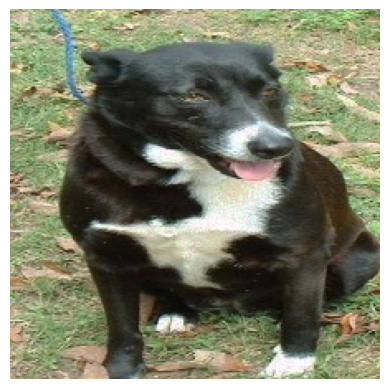

In [25]:
# Test noise_generator_edge()

image = Image.open("/content/sample_data/dog.jpg")

tensor_image = transformTensor(image).to(device)
print(tensor_image.shape[1]*tensor_image.shape[2])
group_tensor_image = multiple_copies_generator(tensor_image, 40)
print(group_tensor_image.shape)

group_tensor_image = noise_generator_edge(group_tensor_image, reach=0.1, divider=56, elite_matrices=200, targeted=True, targeted_channel=1)
test_image = group_tensor_image[0]

image_restored = transformPIL(test_image)
plt.imshow(image_restored)
plt.axis("off")
plt.show

# **MAIN CODE**
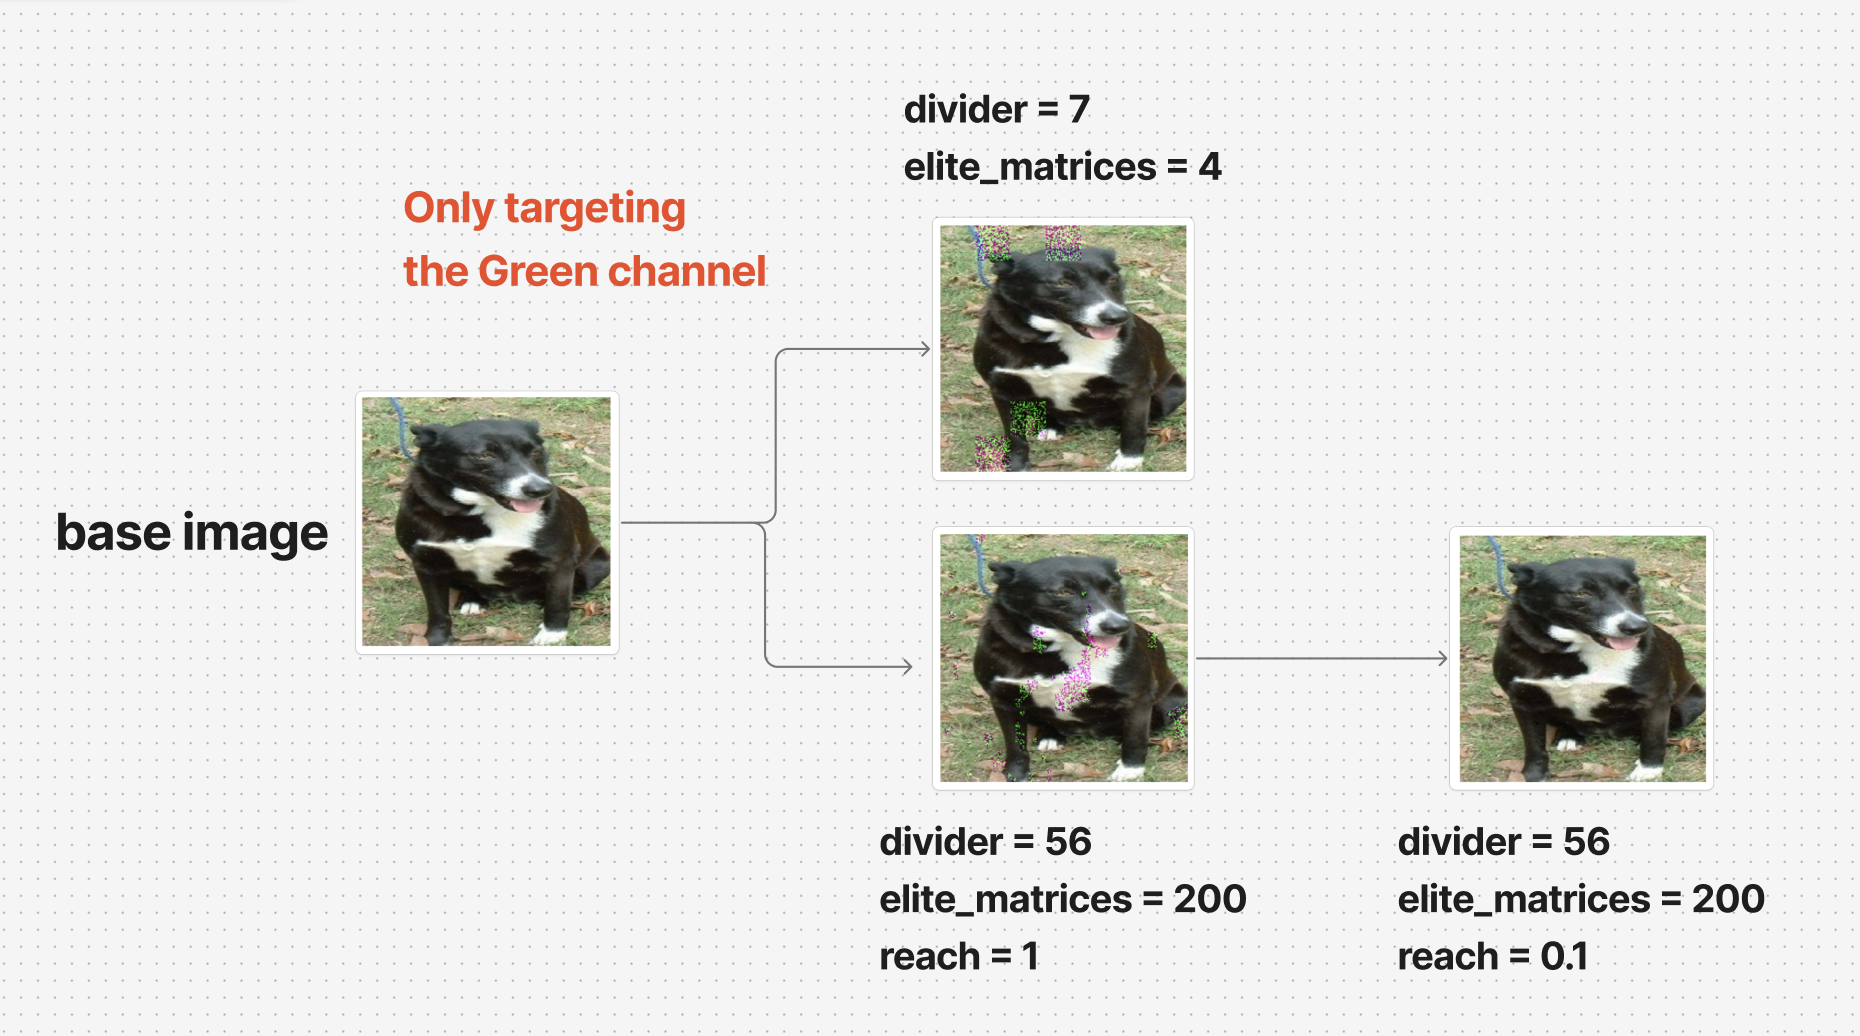

In [ ]:
# EDGE VERSION WITH noise_generator_edge()

# WITH ADDITIONAL NOISE -> ADS UP
# ⚙️ HYPERPARAMETERS

# Free GPU cache
torch.cuda.empty_cache()

ENUMS = 500

WANTED_CLASS = 0
UNWANTED_CLASS = 1 # not used

# HEIGHT need relatively big to modify multiple sub_matrices
HEIGHT = 0.25 # significantly increse running time; its the height of the crossover square

REACH = 0.2 # value added to each pixel -> -REACH <= x <= REACH
REACH_NOISE = 0.01 # to add really small mutations

ELITES = 10


MANUAL = False

# MANUAL = True -> You specify how many sub_matrices to modify yourself
# MANUAL = False -> You specify the min pourcentage of the image that you want to modify

if MANUAL:

  DIVIDER = 56 # 1, 2, 4, 7, 8, 14, 16, 28, 32, 56, 112, 224 -> we are working with 224x224, we need divider of 224
  ELITES_MATRICES = 200
  ELITES_MATRICES_NOISE = 50

  # Keep in mind that you are modifying (ELITES_MATRICES / (DIVIDER**2)) * 100
                                        # (4/49) * 100 =  8% of the base image
                                        # And 8/3 = 2.7% in the case where we target 1 channel

  # check if the parameters are valid just in case
  # I may stop checking because having errors can be valuable

  DIVIDER = 7 if DIVIDER % 224 != 0 else DIVIDER # I take 7 rather than looking for the closest divider in the case where the divider isn't valid 😅
  ELITES_MATRICES = min(ELITES_MATRICES, DIVIDER**2)
  ELITES_MATRICES_NOISE = min(ELITES_MATRICES_NOISE, DIVIDER**2)

else:

  MIN_POURCENTAGE = 0.6
  MIN_POURCENTAGE_NOISE = 0.2
  DIVIDER = 56 # 1, 2, 4, 7, 8, 14, 16, 28, 32, 56, 112, 224 -> we are working with 224x224, we need divider of 224

  DIVIDER = 7 if DIVIDER % 224 != 0 else DIVIDER # I take 7 rather than looking for the closest divider in the case where the divider isn't valid 😅

  # Don't touch those -> no need to as they are going to be computed to match MIN_POURCENTAGE!
  ELITES_MATRICES = 0
  ELITES_MATRICES_NOISE = 0

  while (ELITES_MATRICES*100)/DIVIDER**2 < MIN_POURCENTAGE:
    DIVIDER = 7 # 1, 2, 4, 7, 8, 14, 16, 28, 32, 56, 112, 224 -> we are working with 224x224, we need divider of 224
    ELITES_MATRICES += 1

  while (ELITES_MATRICES_NOISE*100)/DIVIDER**2 < MIN_POURCENTAGE_NOISE:
    DIVIDER = 7 # 1, 2, 4, 7, 8, 14, 16, 28, 32, 56, 112, 224 -> we are working with 224x224, we need divider of 224
    ELITES_MATRICES_NOISE += 1


TARGETED = True
TARGETED_CHANNEL = 1

THRESHOLD = 0.6 # sucess if the image is considered (THRESHOLD*10)% of the wanted class -> 0.6 = 60% of the wanted class

# 🧑‍🎨 LOAD AND PROCESS THE BASE IMAGE
image = Image.open("/content/sample_data/dog.jpg")

tensor_image = transformTensor(image).to(device)
multiple_copies = multiple_copies_generator(tensor_image, 40)

multiple_copies = noise_generator_edge(multiple_copies, reach=REACH, elite_matrices=ELITES_MATRICES, targeted=TARGETED, targeted_channel=TARGETED_CHANNEL)

# 🤖 MODEL AND SELECTION
probabilities = through_model(multiple_copies)
elites_selection, middle_selection, elites_index, elites_proba = selection(multiple_copies, probabilities, ELITES, WANTED_CLASS, UNWANTED_CLASS, wanted=True)

predicted_classes = torch.argmax(probabilities, dim=-1) # return the classes that the model predicted for each image
print(predicted_classes) # Just for the visual

for i in range(ENUMS):
  print(i)

  # 👨‍💻 COMPUTE EACH SPLIT (20-20) => 40

  top_selection = torch.cat((elites_selection, middle_selection)).clone() # no need for clone here i might remove it after checking

  # 20 -> add noise
  noise_selection = noise_generator_edge(top_selection, reach=REACH_NOISE, elite_matrices=ELITES_MATRICES_NOISE, targeted=TARGETED, targeted_channel=TARGETED_CHANNEL) # must be really small -> it adds up with the iterations

  # 20 -> crossover
  parents_index = parent_generator_fixed(top_selection)
  crossed_copies = crossover_generator(top_selection, parents_index, pourcentage_height=HEIGHT)

  # 20 + 20 = 40 index
  multiple_copies = torch.cat((crossed_copies, noise_selection)) # concatenate the splits together

  # ❗️Now we have the final image set for this iteration to pass through the model!

  # 🤖 MODEL AND SELECTION
  probabilities = through_model(multiple_copies)

  probabilities_wanted = probabilities[:, WANTED_CLASS]
  print(probabilities_wanted)
  print(probabilities_wanted.sum().item())

  elites_selection, middle_selection, elites_index, elites_proba = selection(multiple_copies, probabilities, ELITES, WANTED_CLASS, UNWANTED_CLASS, wanted=True)

  # 👍 RESULTS FOUND?/ HOW GOOD ARE THEY?
  success, success_index = checker(elites_index, elites_proba, THRESHOLD)
  if success:
    print("Adversarial image found!")
    adv_image = multiple_copies[success_index]

    # 🥸 DISPLAY BEST IMAGE
    image_restored = transformPIL(adv_image)
    plt.imshow(image_restored)
    plt.axis("off")
    plt.show

    break